# importing important libraries

In [2]:
from sklearn.datasets import fetch_openml
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import r2_score, explained_variance_score, confusion_matrix, accuracy_score, classification_report, mean_absolute_error
import seaborn as sns
     

In [4]:
mnist = fetch_openml('mnist_784')


In [5]:
x, y = mnist['data'], mnist['target']

In [8]:
x = np.array(x)
y = np.array(y)
     

In [10]:
x.shape


(70000, 784)

In [12]:

y = y.astype('int')


In [14]:
x_train, x_test = x[:60000], x[60000:70000]
y_train, y_test = y[:60000], y[60000:70000]
     

In [16]:
x_train.shape

(60000, 784)

In [18]:
x_test.shape
     

(10000, 784)

In [20]:
y_train.shape

(60000,)

In [22]:
y_test.shape
     

(10000,)

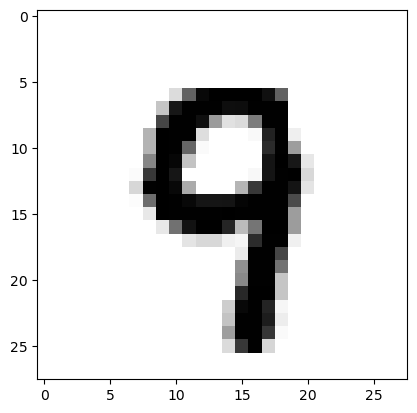

In [24]:
some_image = x[520]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')
     

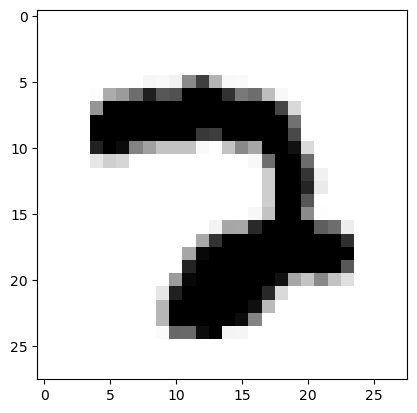

In [26]:
some_image = x[120]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')
     

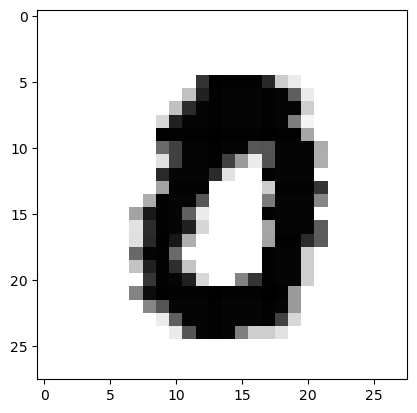

In [28]:
some_image = x[69]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

# Applying DecisionTreeRegressor as base model
# Assumption depth size 1

In [31]:
lr = 0.1   #learning rate
     

In [33]:
dt = DecisionTreeRegressor(max_depth = 1)
dt.fit(x_train,y_train)
     


DecisionTreeRegressor(max_depth=1)

In [35]:
DecisionTreeRegressor(max_depth=1)

DecisionTreeRegressor(max_depth=1)

In [37]:
y_pred = dt.predict(x_test)

In [39]:
y_pred[:10]

array([5.36713732, 2.6254691 , 2.6254691 , 2.6254691 , 5.36713732,
       2.6254691 , 5.36713732, 5.36713732, 2.6254691 , 5.36713732])

In [41]:
mae = mean_absolute_error(y_test,  y_pred)
mae

2.2267110373114707

In [43]:

score = r2_score(y_test, y_pred)
score
     

0.22100481734722877

In [45]:
y_pred = np.round(y_pred)
     

In [47]:
print(accuracy_score( y_test, y_pred))    # accuracy
     

0.0716


# Iteration 1

In [50]:
y_it1 = dt.predict(x_train)
y_it1 = np.round(y_it1)
     

In [52]:
y_train1 = y_train - y_it1

In [54]:
dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(x_train,  y_train1)
     

DecisionTreeRegressor(max_depth=1)

In [56]:
y_pred1 = dt1.predict(x_test)
y_pred1 = np.round(y_pred1)
print(accuracy_score( y_test, y_pred + y_pred1 ))

0.1238


# Iteration 2

In [59]:
y_it2 = dt1.predict(x_train)
y_it2 = np.round(y_it2)

In [61]:
y_train2 = y_train1 - y_it2